# B04 · Pandas 与 Matplotlib

> 阶段〇第 4 周。真实实验数据是「带时间戳、带表头、有缺测」的表格——
> pandas 负责清洗与分析，matplotlib 负责出规范图。
> 这套「读数据 → 清洗 → 聚合 → 出报告图」流水线，就是以后写 RL 训练日志分析的模板。

## 学习目标

1. 用 pandas 读写 CSV，查看 `head / describe / info`；
2. 按条件筛选行、按时间分组聚合（`groupby` / `resample`）；
3. 识别并处理缺失值（`isna / fillna / interpolate`）；
4. 用 matplotlib 的 **figure/axes 接口**画规范图：标签、图例、网格、子图、保存 PNG；
5. 完成一个「温度传感器数据分析」小案例。

## 1. 造一份「像真的」传感器数据

没有真传感器，就合成一份：24 小时温度记录（5 分钟一个点），
含日变化趋势 + 测量噪声 + 随机缺测——和真实数据的三要素一一对应。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# 定位项目根目录，产物统一放 runs/00_basic/（已 gitignore）
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
RUNS = PROJECT_ROOT / "runs" / "00_basic"
RUNS.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(7)
n = 288                                    # 24 h × 每 5 min 一个点
t_index = pd.date_range("2026-08-01", periods=n, freq="5min")
hours = np.arange(n) * 5 / 60
temp = 25 + 5 * np.sin(2 * np.pi * (hours - 9) / 24) + rng.normal(0, 0.4, n)
temp[rng.choice(n, 8, replace=False)] = np.nan      # 随机 8 个缺测点

df = pd.DataFrame({"temperature": temp}, index=t_index)
df.index.name = "timestamp"
df.to_csv(RUNS / "b04_temperature.csv")
print("已写入:", RUNS / "b04_temperature.csv")
df.head()

已写入: /data/wangf/robot_rl_learn/runs/00_basic/b04_temperature.csv


,temperature
timestamp,
2026-08-01 00:00:00,21.464958
2026-08-01 00:05:00,21.507678
2026-08-01 00:10:00,21.203958
2026-08-01 00:15:00,20.884564
2026-08-01 00:20:00,20.987909


## 2. 读入与初检

拿到任何数据先做「三看」：`head()` 看长相、`info()` 看类型与缺失、`describe()` 看统计分布。

In [2]:
df = pd.read_csv(RUNS / "b04_temperature.csv", parse_dates=["timestamp"], index_col="timestamp")
print(df.head(3))
print()
df.info()
print()
print(df.describe().round(3))
print("\n缺失点数:", df["temperature"].isna().sum())

                     temperature
timestamp                       
2026-08-01 00:00:00    21.464958
2026-08-01 00:05:00    21.507678
2026-08-01 00:10:00    21.203958

<class 'pandas.DataFrame'>
DatetimeIndex: 288 entries, 2026-08-01 00:00:00 to 2026-08-01 23:55:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  280 non-null    float64
dtypes: float64(1)
memory usage: 4.5 KB

       temperature
count      280.000
mean        24.932
std          3.565
min         19.112
25%         21.507
50%         24.903
75%         28.355
max         30.515

缺失点数: 8


## 3. 缺失值处理

缺测点直接参与平均会污染结果（pandas 默认跳过 NaN，但绘图会断线）。常用策略：

- `fillna`：填固定值 / 前一个值（`ffill`）—— 简单粗暴；
- `interpolate`：线性插值 —— 时间序列缺测的首选。

In [3]:
df["temp_interp"] = df["temperature"].interpolate(method="linear")

nan_idx = df.index[df["temperature"].isna()]
print("缺测时刻:", [str(t.time()) for t in nan_idx])
print("\n插值前后对照（前 3 个缺测点）:")
print(df.loc[nan_idx[:3], ["temperature", "temp_interp"]].round(3))

缺测时刻: ['01:15:00', '03:00:00', '09:40:00', '10:35:00', '15:15:00', '17:10:00', '18:45:00', '23:55:00']

插值前后对照（前 3 个缺测点）:
                     temperature  temp_interp
timestamp                                    
2026-08-01 01:15:00          NaN       20.242
2026-08-01 03:00:00          NaN       20.017
2026-08-01 09:40:00          NaN       25.486


## 4. 筛选与分组聚合

- **布尔筛选**：`df[df["col"] > 阈值]`，和 NumPy 掩码一脉相承；
- **`groupby`**：按类别分组聚合（按小时、按设备、按实验批次）；
- **`resample`**：时间序列专用的分组——重采样到小时/天粒度。

In [4]:
# 筛选：所有高于 29 度的时刻
hot = df[df["temp_interp"] > 29.0]
print(f"高温（>29 degC）样本数: {len(hot)} / {len(df)}")

# groupby：按「小时」分组统计
hourly_gb = df.groupby(df.index.hour)["temp_interp"].agg(["mean", "max", "min"])
print("\n按小时聚合（前 6 行）:")
print(hourly_gb.head(6).round(2))

# resample：重采样为每小时一行（时间序列专用，结果仍带时间索引）
hourly = df[["temp_interp"]].resample("1h").mean()
hourly.columns = ["hourly_mean"]
print("\nresample 结果（前 3 行）:")
print(hourly.head(3).round(2))

高温（>29 degC）样本数: 57 / 288

按小时聚合（前 6 行）:
            mean    max    min
timestamp                     
0          21.04  21.51  20.59
1          20.09  20.71  19.56
2          19.85  20.43  19.11
3          20.05  20.62  19.48
4          20.49  21.14  19.79
5          20.89  21.57  20.37

resample 结果（前 3 行）:
                     hourly_mean
timestamp                       
2026-08-01 00:00:00        21.04
2026-08-01 01:00:00        20.09
2026-08-01 02:00:00        19.85


## 5. Matplotlib 规范出图

新手常写 `plt.plot(...)` 一把梭，工程上推荐 **figure/axes 显式接口**：
`fig, ax = plt.subplots()`，之后所有操作都对着 `ax` 来——多子图时不会乱。

规范图检查清单（对照实验报告要求）：

- [ ] 坐标轴标签带**单位**（`set_xlabel("Time (h)")`）
- [ ] 多条曲线有**图例**（`label=` + `legend()`）
- [ ] 有**网格**（`grid(alpha=0.3)`）方便读数
- [ ] 标题说明图的内容
- [ ] 保存文件：`fig.savefig(..., dpi=150, bbox_inches="tight")`

> 约定：图内文字用英文，避免 matplotlib 默认字体缺中文字形导致的方框乱码。

报告图已保存: /data/wangf/robot_rl_learn/runs/00_basic/b04_temperature_report.png


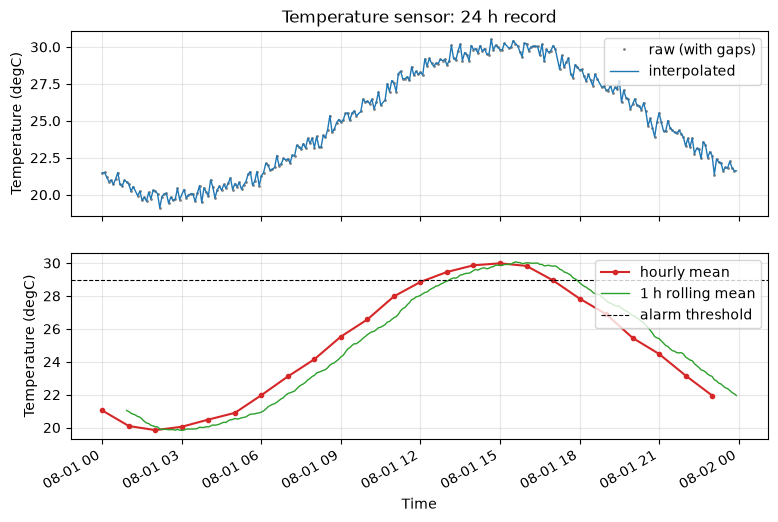

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# 子图 1：原始数据（含缺测断线） vs 插值结果
axes[0].plot(df.index, df["temperature"], ".", ms=2, color="gray", label="raw (with gaps)")
axes[0].plot(df.index, df["temp_interp"], "-", lw=1, color="tab:blue", label="interpolated")
axes[0].set_ylabel("Temperature (degC)")
axes[0].set_title("Temperature sensor: 24 h record")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# 子图 2：按小时的均值与极值带
axes[1].plot(hourly.index, hourly["hourly_mean"], "-o", ms=3, color="tab:red", label="hourly mean")
axes[1].plot(df.index, df["temp_interp"].rolling(12).mean(), lw=1, color="tab:green",
             label="1 h rolling mean")
axes[1].axhline(29.0, ls="--", color="k", lw=0.8, label="alarm threshold")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Temperature (degC)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

fig.autofmt_xdate()   # 时间标签自动倾斜防重叠
png_path = RUNS / "b04_temperature_report.png"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
print("报告图已保存:", png_path)
plt.show()

**读图**：上子图灰点是原始采样（缺测处断线），蓝线是线性插值——缺测点被平滑补上；
下子图可见 14 时左右温度峰值越过 29 ℃ 报警线，与 `hot` 筛选结果一致。

## 小结与衔接

- 流水线记住五步：`read_csv → info/describe → 缺失值处理 → 筛选/聚合 → 规范出图存 PNG`；
- pandas 的布尔筛选、向量化列运算与 NumPy 完全同源；
- 这张「传感器报告图」的版式（双子图、图例、网格、阈值线）可以直接搬去写实验报告。

**下周 B05（重点课）**：`scipy.solve_ivp` 数值求解微分方程——
一阶环节、RLC、弹簧阻尼、单摆，把「数值模拟」从欧拉手写升级为专业工具。

---

## ✏️ 练习

> 规则：先独立完成，再点开折叠的参考答案核对。

**练习 1（★，10 分钟，10 分）——找出全天最高温**
从插值后的数据中找出：最高温度值、出现时刻、以及全天温度超过 28 ℃ 的总时长（小时）。
**交付物**：三个打印值。

**练习 2（★，10 分钟，10 分）——分时段统计**
把一天分成「凌晨(0-6) / 上午(6-12) / 下午(12-18) / 晚上(18-24)」四段
（提示：`pd.cut` 或对 `df.index.hour` 做映射），用 `groupby` 求每段的平均温度与最大温度。
**交付物**：4 行统计表。

**练习 3（★★，20 分钟，20 分）——缺测率敏感性实验**
重新合成数据，分别随机置 1%、5%、10% 的点为 NaN，线性插值后与「无缺失真值」比较，
计算三种缺测率下的 RMSE（均方根误差），打印对比表。
**交付物**：三行 RMSE 结果 + 一句话结论（插值在缺测率多高时仍可用）。

**练习 4（★，10 分钟，10 分）——出一张自己的报告图**
把练习 1 的数据画成单图：原始散点 + 插值曲线 + 最高温标记（`axvline` 或散点高亮），
包含标题/轴标签/图例/网格，保存 PNG 到 `runs/00_basic/b04_ex4.png`。
**交付物**：图 + 保存路径打印。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：

```python
s = df["temp_interp"]
t_max = s.idxmax()
print("最高温度:", round(s.max(), 2), "degC @", t_max)
print("超过 28 degC 时长:", (s > 28).sum() * 5 / 60, "h")   # 每点 5 min
```

**练习 2**：

```python
period = pd.cut(df.index.hour, bins=[-1, 5, 11, 17, 23],
                labels=["dawn", "morning", "afternoon", "evening"])
print(df.groupby(period)["temp_interp"].agg(["mean", "max"]).round(2))
```

**练习 3**：

```python
truth = 25 + 5 * np.sin(2 * np.pi * (hours - 9) / 24) + rng.normal(0, 0.4, n)
for rate in [0.01, 0.05, 0.10]:
    corrupted = truth.copy()
    corrupted[rng.choice(n, int(n * rate), replace=False)] = np.nan
    est = pd.Series(corrupted).interpolate().to_numpy()
    rmse = np.sqrt(np.mean((est - truth) ** 2))
    print(f"missing {rate:.0%}: RMSE = {rmse:.3f} degC")
# 结论：缺测率 10% 内线性插值 RMSE 都远小于噪声水平(0.4)，足够用
```

**练习 4**：在 5.1 节代码基础上加：

```python
ax.scatter([s.idxmax()], [s.max()], color="red", zorder=5, label="peak")
fig.savefig(RUNS / "b04_ex4.png", dpi=150, bbox_inches="tight")
```

</details>

---

## 延伸阅读

- [pandas 10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [pandas 时间序列（resample）指南](https://pandas.pydata.org/docs/user_guide/timeseries.html)
- [matplotlib 官方教程（pyplot vs 面向对象接口）](https://matplotlib.org/stable/users/explain/quick_start.html)
- 《利用 Python 进行数据分析》第 5、7、9 章